# Compare pool metrics
Load all metrics parquets from `artifacts/` and compare MAE, RMSE, MAPE across models (baseline, lstm, xgboost, lightgbm, xgb_lstm_stack, chronos).

In [5]:
from pathlib import Path
import pandas as pd

ARTIFACTS_DIR = Path.cwd() / "artifacts"

files = {
    "baseline": "metrics_baseline_pool.parquet",
    "lstm": "metrics_lstm_pool.parquet",
    "xgboost": "metrics_xgboost_pool.parquet",
    "lightgbm": "metrics_lightgbm_pool.parquet",
    "xgb_lstm_stack": "metrics_xgb_lstm_stack_pool.parquet",
    "chronos": "metrics_chronos_pool.parquet",
}
dfs = []
for name, f in files.items():
    p = ARTIFACTS_DIR / f
    if p.exists():
        df = pd.read_parquet(p)
        dfs.append(df)
    else:
        print(f"Missing: {p}")

if not dfs:
    raise SystemExit("No metrics files found. Run 01–04 pool notebooks first.")
all_metrics = pd.concat(dfs, ignore_index=True)
print("Overall :")
overall = all_metrics[all_metrics["symbol"] == "overall"].sort_values('MAE')
overall

Overall :


,model,symbol,MAE,RMSE,MAPE_%
65,chronos,overall,11.112044,14.951325,4.349936
21,lstm,overall,11.131069,14.906411,4.406365
43,lightgbm,overall,11.187229,15.427596,4.268077
32,xgboost,overall,11.311873,15.539589,4.302133
10,baseline,overall,11.755865,15.041273,4.601217
54,xgb_lstm_stack,overall,11.798155,16.665939,4.367110


In [6]:
all_metrics

,model,symbol,MAE,RMSE,MAPE_%
0,baseline,AAPL,10.576515,12.508965,3.993837
1,baseline,MSFT,20.227439,23.984635,4.761016
2,baseline,GOOGL,14.949737,16.611171,4.633056
3,baseline,AMZN,13.883547,16.152378,6.272374
4,baseline,JPM,11.060196,12.891812,3.517454
...,...,...,...,...,...
61,chronos,WMT,4.884244,5.593501,3.968512
62,chronos,SPY,6.521761,7.735084,0.948906
63,chronos,XOM,8.155644,9.521872,5.866924
64,chronos,NVDA,7.434028,8.641304,4.034546


In [7]:
# Pivot: rows = symbol (or overall), columns = model, values = MAE / RMSE / MAPE_%
for metric in ["MAE", "RMSE", "MAPE_%"]:
    if metric not in all_metrics.columns:
        continue
    pt = all_metrics.pivot_table(index="symbol", columns="model", values=metric)
    print(f"\n--- {metric} ---")
    print(pt.to_string())
    print()


--- MAE ---
model     baseline    chronos   lightgbm       lstm  xgb_lstm_stack    xgboost
symbol                                                                        
AAPL     10.576515  11.120810  10.855679  11.089841       11.134277  11.025909
AMZN     13.883547  13.742466  13.781546  15.033721       14.358289  13.800689
GOOGL    14.949737  13.156044  13.298114  13.851236       13.676755  13.597635
JNJ      12.283744  11.570445   9.582916  10.833193        8.718291   9.586452
JPM      11.060196  10.471748  10.752822  11.089579       11.787064  10.633022
MSFT     20.227439  24.063253  26.519576  21.391627       29.143193  26.574246
NVDA      7.207861   7.434028   6.657137   6.179744        6.864212   6.763804
SPY      11.581101   6.521761   7.900878   7.382664       10.696334   8.521104
WMT       5.970048   4.884244   4.945941   6.012216        4.567406   4.996208
XOM       9.818460   8.155644   7.577680   8.446863        7.035725   7.619658
overall  11.755865  11.112044  11.18722

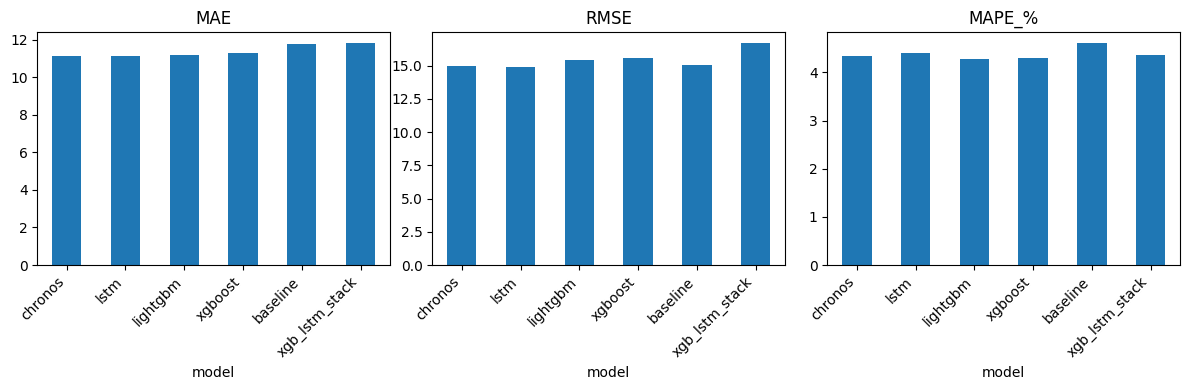

In [8]:
# Overall row only: bar comparison

if overall.empty:
    overall = all_metrics.groupby("model").agg({"MAE": "mean", "RMSE": "mean", "MAPE_%": "mean"}).reset_index()

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, col in zip(axes, ["MAE", "RMSE", "MAPE_%"]):
    if col in overall.columns:
        overall.plot(x="model", y=col, kind="bar", ax=ax, legend=False)
        ax.set_title(col)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()